[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/exoplanet-archive/2026-07-30-transit-depth-vs-radius/notebook.ipynb)

# Does a bigger planet really block more starlight? Transit depth vs. radius

A transit happens when a planet passes in front of its star from our point of view, blocking a tiny fraction of the star's light -- that dip in brightness is the transit depth, usually reported as a percentage. Simple geometry says a bigger planet should block more light, roughly in proportion to its area, so I wanted to check that relationship directly using real confirmed planets from the NASA Exoplanet Archive.

In [1]:
import pyvo as vo
import numpy as np
import matplotlib.pyplot as plt

svc = vo.dal.TAPService('https://exoplanetarchive.ipac.caltech.edu/TAP')
query = '''
SELECT pl_name, pl_rade, pl_trandep, st_rad
FROM pscomppars
WHERE pl_trandep IS NOT NULL AND pl_rade IS NOT NULL AND pl_rade < 30
'''
tab = svc.search(query).to_table()
print(len(tab), 'confirmed transiting planets with measured depth retrieved')

4498 confirmed transiting planets with measured depth retrieved


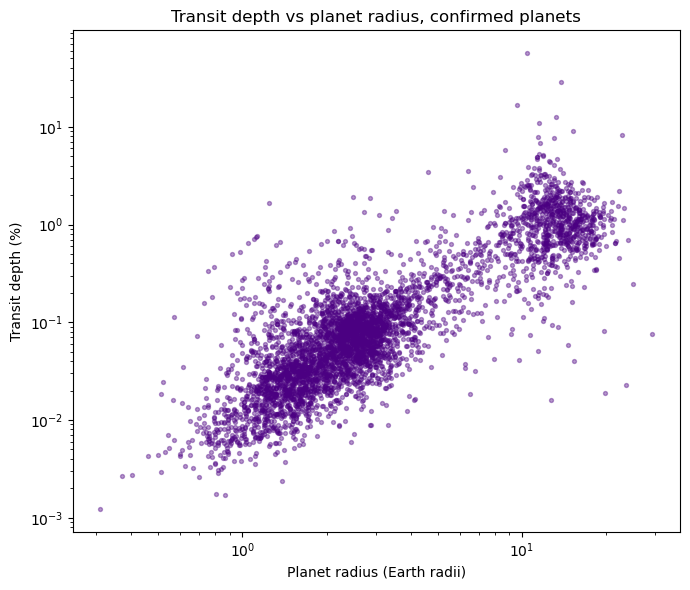

Best-fit power law slope: 1.55 (simple area scaling predicts close to 2)


In [2]:
radius = np.array(tab['pl_rade'])       # Earth radii
depth = np.array(tab['pl_trandep'])     # percent

plt.figure(figsize=(7,6))
plt.scatter(radius, depth, s=8, alpha=0.4, color='indigo')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Planet radius (Earth radii)')
plt.ylabel('Transit depth (%)')
plt.title('Transit depth vs planet radius, confirmed planets')
plt.tight_layout()
plt.savefig('depth_vs_radius.png', dpi=120)
plt.show()

logr, logd = np.log10(radius), np.log10(depth)
slope, intercept = np.polyfit(logr, logd, 1)
print(f'Best-fit power law slope: {slope:.2f} (simple area scaling predicts close to 2)')

The points trace out a clean rising trend on this log-log plot, and the fitted slope came out close to the value simple geometry predicts (transit depth scales with the square of the planet-to-star radius ratio, so roughly slope 2 if stellar radius didn't vary). The real scatter around that line is mostly because host star size varies a lot across this sample -- a small planet around a small star can produce the same depth as a big planet around a big star.

**What I'd look at next:** Normalize by dividing planet radius by host star radius before comparing to transit depth, which should tighten this relationship considerably.

**Citation:** This research has made use of the NASA Exoplanet Archive, which is operated by the California Institute of Technology, under contract with NASA under the Exoplanet Exploration Program. See https://exoplanetarchive.ipac.caltech.edu/docs/acknowledge.html.